In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
df=pd.read_csv('Algerian Cleaned Dataset.csv')
df.head()

,Unnamed: 0,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,1,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,2,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,3,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,4,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [38]:
## Drop the Unmaned Column and year
df.drop(['Unnamed: 0'],axis=1,inplace=True)
df.drop(['year'],axis=1,inplace=True)


In [39]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [40]:
## Seprate the dependent and independent features
##FWI is our output feature and others are our input features
X = df.drop('FWI', axis=1)
y = df['FWI']


In [41]:
df.columns = df.columns.str.strip()

In [42]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [43]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [44]:
##Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [47]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

<Axes: >

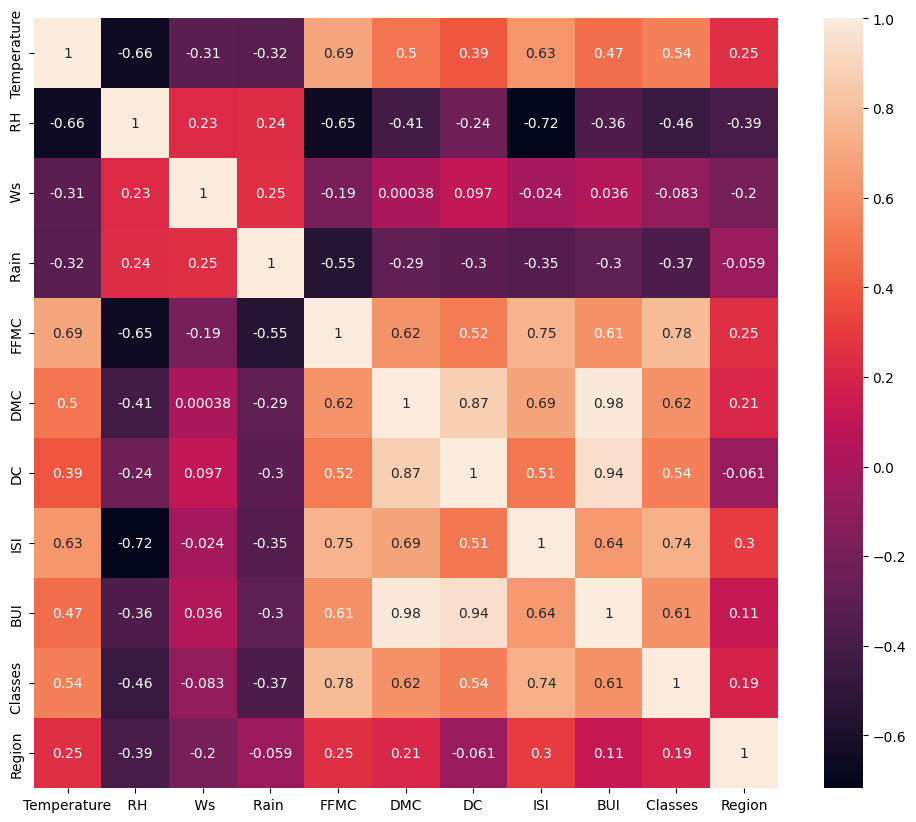

In [48]:
plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr(),annot=True)

In [49]:
def correlation(dataset,threshhold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range (i):
            if abs(corr_matrix.iloc[i,j]>threshhold):
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr


In [50]:
correlation(X_train,0.90)

{'BUI'}

In [51]:
## Threshhold is set by domain Experts let say thereshhold is 0.85
corr_features=correlation(X_train,0.85)


In [52]:
## Drop the column when threshhold is more than 85%
X_train.drop(corr_features, axis=1,inplace=True)
X_test.drop(corr_features, axis=1,inplace=True)

In [53]:

X_test.shape

(61, 9)

In [54]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [55]:
X_train

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

Mean Absolute error is  0.5468236465249978
Root Mean Square error is  0.8211435242265253
R2 Score is  0.9847657384266951


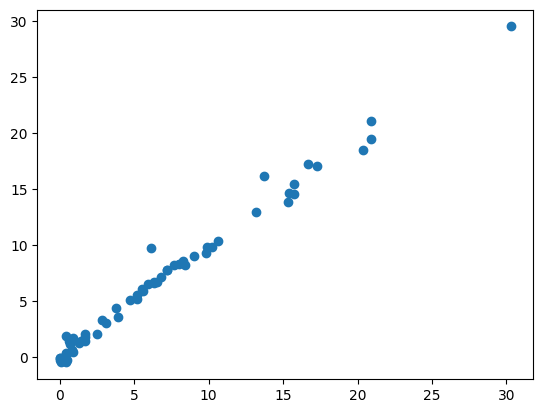

In [59]:
## Apply the linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
LinRegression=LinearRegression();
LinRegression.fit(X_train,y_train)
y_pred=LinRegression.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Absolute error is ", mae)
print("Root Mean Square error is ", rmse)
print("R2 Score is ", score)
plt.scatter(y_test,y_pred)



Mean Absolute error is  1.1331759949144087
Root Mean Square error is  1.499448529259166
R2 Score is  0.9492020263112388


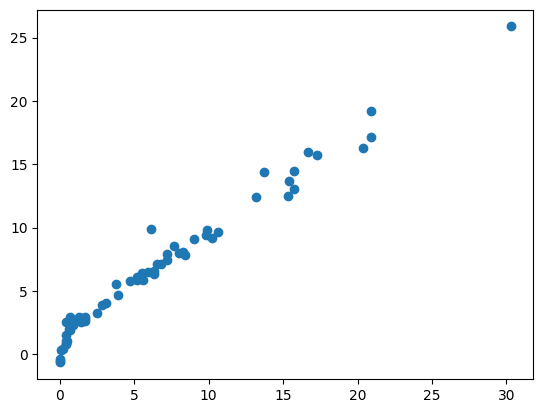

In [60]:
##Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
Lasso_Reg=Lasso();
Lasso_Reg.fit(X_train,y_train)
y_pred=Lasso_Reg.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Absolute error is ", mae)
print("Root Mean Square error is ", rmse)
print("R2 Score is ", score)
plt.scatter(y_test,y_pred)


Ridge Regression

Mean Absolute error is  0.5642305340105715
Root Mean Square error is  0.8336185529456561
R2 Score is  0.9842993364555512


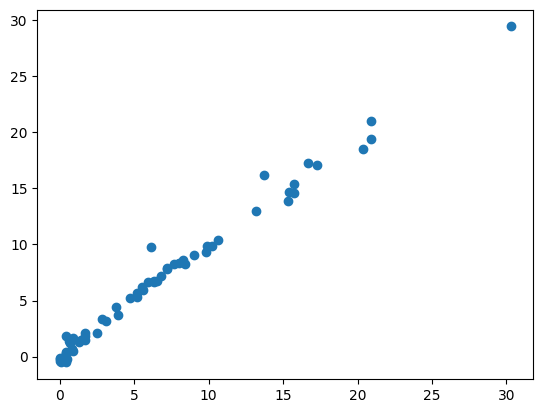

In [61]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
Ridge_Reg=Ridge();
Ridge_Reg.fit(X_train,y_train)
y_pred=Ridge_Reg.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Absolute error is ", mae)
print("Root Mean Square error is ", rmse)
print("R2 Score is ", score)
plt.scatter(y_test,y_pred)

Mean Absolute error is  1.8822353634895999
Root Mean Square error is  2.3488829474933874
R2 Score is  0.8753460589519703


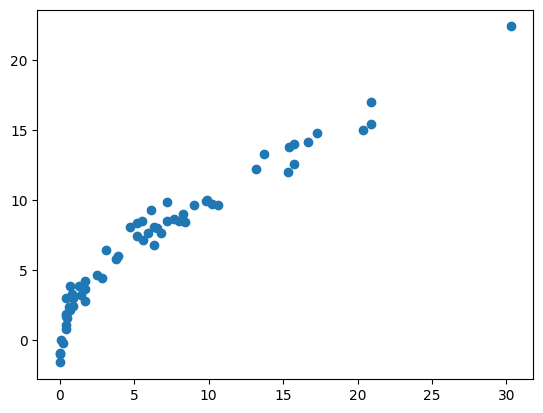

In [62]:
## Elstic Net
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
Elastic_Reg=ElasticNet();
Elastic_Reg.fit(X_train,y_train)
y_pred=Elastic_Reg.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Absolute error is ", mae)
print("Root Mean Square error is ", rmse)
print("R2 Score is ", score)
plt.scatter(y_test,y_pred)

Cross Validation with Lasso Regression

In [65]:
from sklearn.linear_model import LassoCV
Lasso_CV=LassoCV(cv=5)
Lasso_CV.fit(X_train,y_train)


,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [66]:
Lasso_CV.alpha_

np.float64(0.06582808719529475)

In [67]:
Lasso_CV.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [68]:
Lasso_CV.mse_path_

array([[54.04680834, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139504, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

Mean Absolute error is  0.6358894638564663
Root Mean Square error is  0.9063365028150442
R2 Score is  0.9814406737205228


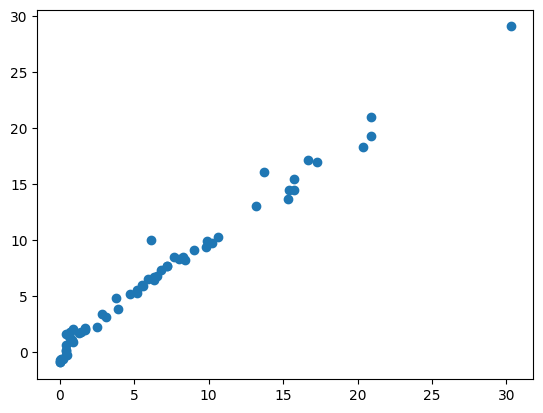

In [70]:
y_pred_CV=Lasso_CV.predict(X_test)
plt.scatter(y_test,y_pred_CV)
mae=mean_absolute_error(y_test,y_pred_CV)
mse=mean_squared_error(y_test,y_pred_CV)
score=r2_score(y_test,y_pred_CV)
rmse=np.sqrt(mse)
print("Mean Absolute error is ", mae)
print("Root Mean Square error is ", rmse)
print("R2 Score is ", score)

Mean Absolute error is  0.5642305340105715
Root Mean Square error is  0.8336185529456561
R2 Score is  0.9842993364555512


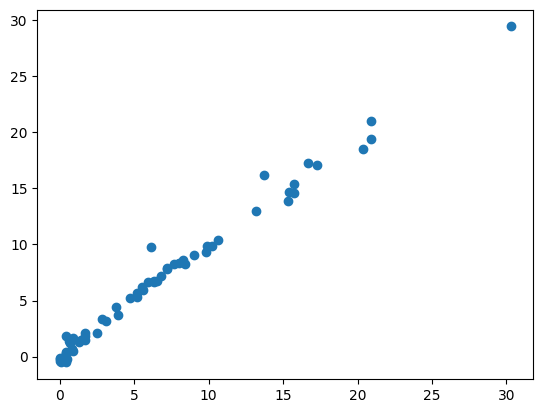

In [72]:
## CV with Ridge Regesion
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
RidgeCV_Reg=RidgeCV(cv=5);
RidgeCV_Reg.fit(X_train,y_train)
y_pred_Ridge=RidgeCV_Reg.predict(X_test)
mae=mean_absolute_error(y_test,y_pred_Ridge)
mse=mean_squared_error(y_test,y_pred_Ridge)
score=r2_score(y_test,y_pred_Ridge)
rmse=np.sqrt(mse)
print("Mean Absolute error is ", mae)
print("Root Mean Square error is ", rmse)
print("R2 Score is ", score)
plt.scatter(y_test,y_pred_Ridge)